In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
#import os
#os.environ["OMP_NUM_THREADS"] = "8"
N_QUBITS = 8
df_data = pd.read_csv('features_geometry_70.csv')

X = df_data.drop(columns=['class', 'image_name'])

y = df_data['class']

#pca = PCA(n_components=N_QUBITS)
#X_pca= pca.fit_transform(X)  

print(X.shape)
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

#X_final = X_pca.copy()


# 2. Normaliza para [0, π] 
# scaler = MinMaxScaler()
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)


classes_existentes = sorted(y.unique()) 
n_classes = len(classes_existentes)



X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y , test_size=0.9, random_state=42, stratify=y
)


print("X_train shape:", X_train.shape)  
print("X_test shape: ", X_test.shape)   
print("Primeira amostra:", X_train[0])

(45014, 51)
X_train shape: (4501, 51)
X_test shape:  (40513, 51)
Primeira amostra: [0.         0.         1.44070943 1.59206535 1.18881707 1.54457445
 0.96053567 1.4979485  1.07699006 1.45959433 1.07868648 2.86779475
 1.14658766 1.86044383 1.1378625  1.6853027  1.15376785 1.60472545
 1.43477026 3.13581289 1.31916097 1.78041975 1.25343387 1.39232067
 1.25333291 1.21453913 1.65708487 2.71820716 1.60801748 1.68027093
 1.64551555 1.32356724 1.696365   1.14835622 1.51124459 2.18572139
 1.78060929 1.60156716 1.8142939  1.34247363 1.82823455 1.19976651
 1.20071614 1.74073814 0.43425456 0.51380376 1.12146761 0.00323889
 1.0929099  0.93842087 0.99602285]


In [ ]:
print(pca.explained_variance_ratio_.cumsum())

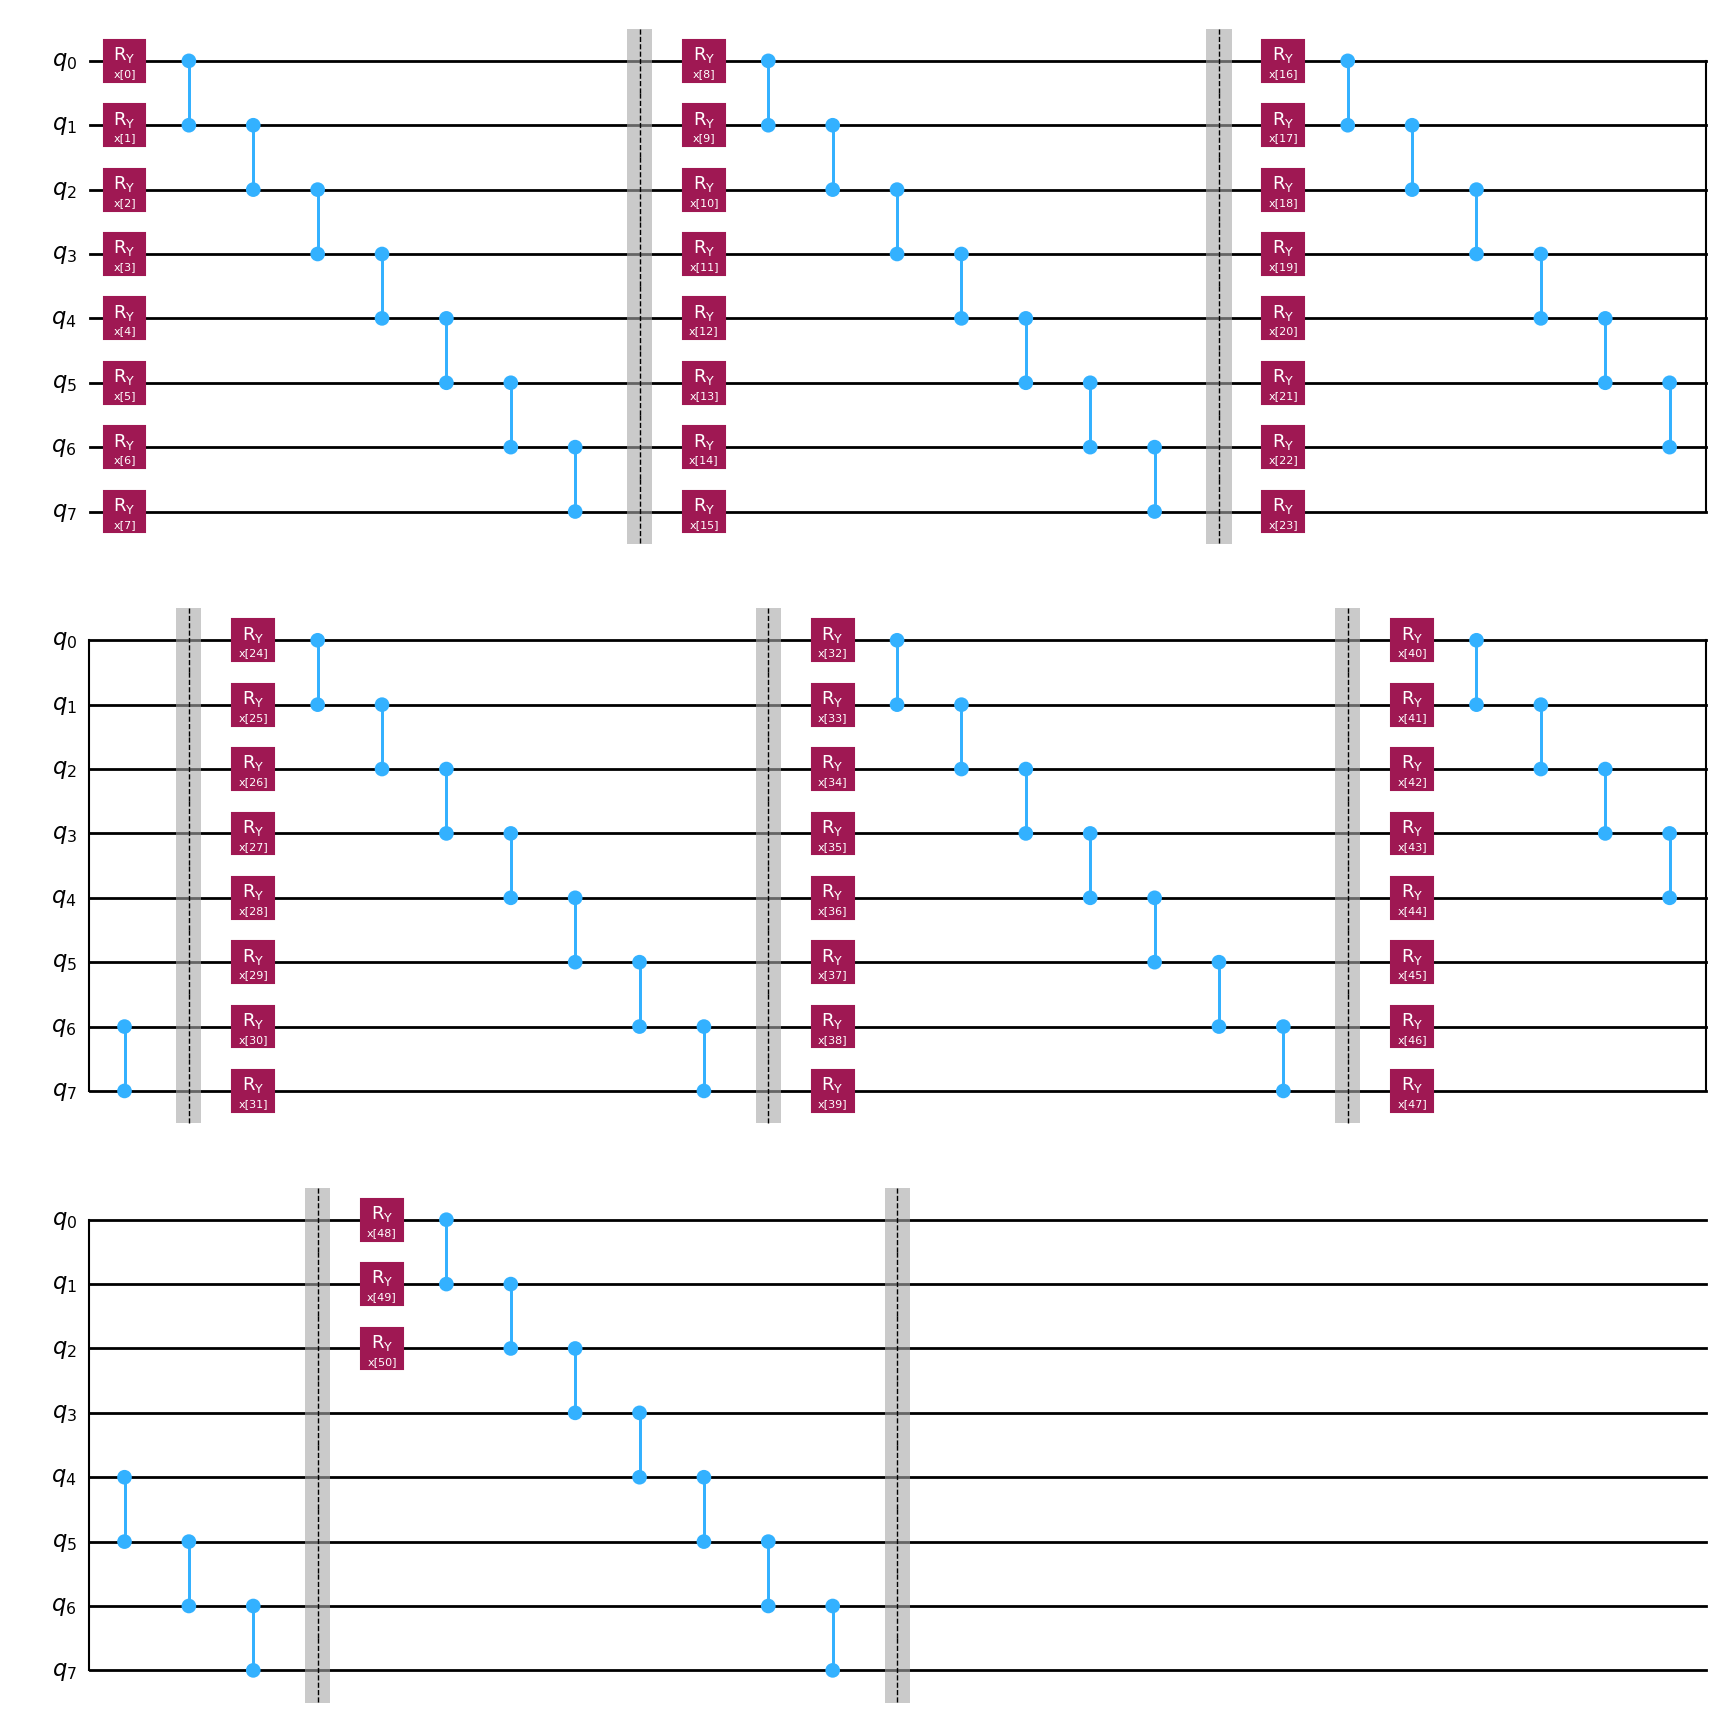

In [2]:
from math import ceil
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

num_features = 51
num_qubits = 8

data_vector = ParameterVector("x", num_features)

def build_data_reupload_only(num_qubits, num_features, data_vector):
    qc = QuantumCircuit(num_qubits)

    num_reuploads = ceil(num_features / num_qubits)
    feature_idx = 0

    for layer in range(num_reuploads):
        for q in range(num_qubits):
            if feature_idx < num_features:
                qc.ry(data_vector[feature_idx], q)
                feature_idx += 1

        for q in range(num_qubits - 1):
            qc.cz(q, q + 1)

        qc.barrier()

    return qc

reupload = build_data_reupload_only(
    num_qubits=num_qubits,
    num_features=num_features,
    data_vector=data_vector
)

reupload.draw("mpl")

In [ ]:
pip install pylatexenc

Usando 8 qubits


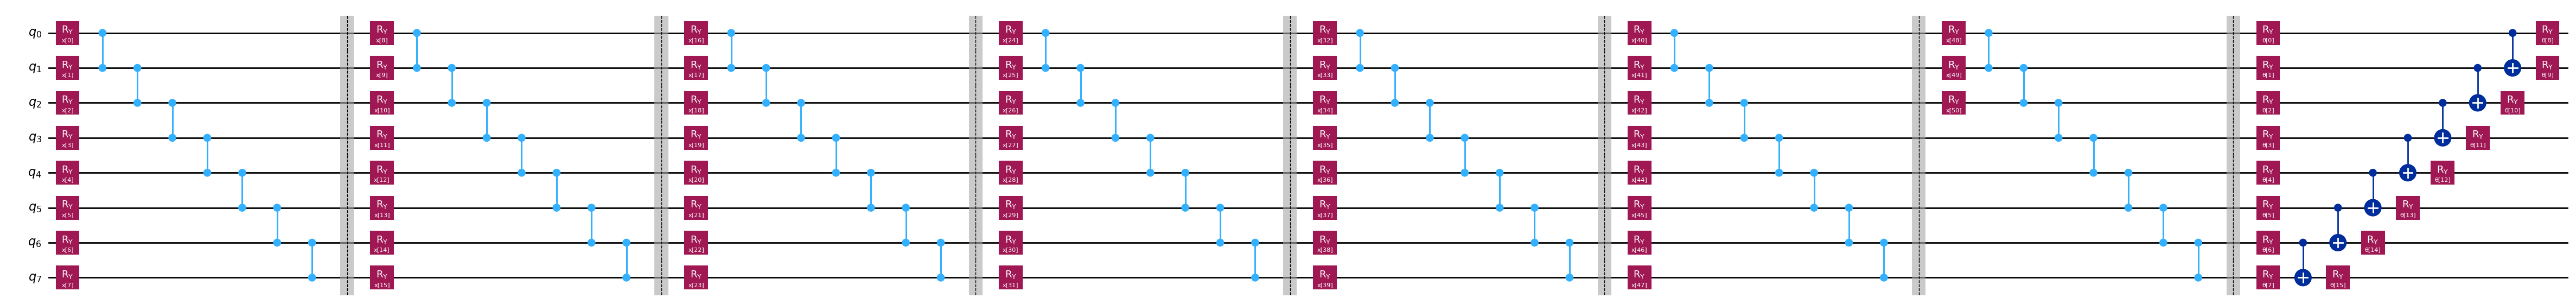

In [3]:
from qiskit.circuit.library import RealAmplitudes
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from sklearn.model_selection import train_test_split


num_features = 8       
print(f"Usando {num_features} qubits")


feature_map = ZZFeatureMap(num_features, reps=1)


ansatz =  RealAmplitudes(num_features, reps=1) 


qc = QuantumCircuit(num_features)
qc.compose(reupload, inplace=True)
qc.compose(ansatz.decompose(), inplace=True)


qc.draw("mpl", fold=-1)

In [4]:
from qiskit.quantum_info import Pauli
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.primitives import StatevectorEstimator
#from qiskit_aer.primitives import Estimator as AerEstimator

#FOR 8 QUBITS
observables = [
    Pauli("ZIIIIIII"),
    Pauli("IZIIIIII"),
    Pauli("IIZIIIII"),
    Pauli("IIIZIIII"),
    Pauli("IIIIZIII"),
    Pauli("IIIIIZII"),
    Pauli("IIIIIIZI"),
    Pauli("IIIIIIIZ"),
]
# observables = [
#     Pauli("ZIIIII"),
#     Pauli("IZIIII"),
#     Pauli("IIZIII"),
#     Pauli("IIIZII"),
#     Pauli("IIIIZI"),
#     Pauli("IIIIIZ"),
# ]

from qiskit_aer.primitives import EstimatorV2 as AerEstimator
estimator = AerEstimator(
    options={
        "backend_options": {
            "method": "statevector",
            "device": "CPU",
            "precision": "double",
            "max_parallel_threads": 16,
            "max_parallel_experiments": 0,
            "blocking_enable": False,
        }
    }
)
qnn = EstimatorQNN(
    circuit=qc,
    input_params=list(data_vector),
    weight_params=ansatz.parameters,
    observables=observables,
    estimator=estimator,
)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


In [5]:
from qiskit_machine_learning.connectors import TorchConnector
import torch
import torch.nn as nn


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

quantum_layer = TorchConnector(qnn)


In [6]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.quantum = quantum_layer
        self.classical = nn.Sequential(
            nn.Linear(N_QUBITS, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 21)
        )
        
    def forward(self, x):
        x = self.quantum(x)
        x = self.classical(x)
        return x

In [7]:
from sklearn.utils import resample

X_train_small, y_train_small = resample(
    X_train, y_train,
    n_samples=1000,
    stratify=y_train,  # keeps class balance
    random_state=42
)

In [8]:
from sklearn.utils.class_weight import compute_class_weight

X_tensor = torch.tensor(X_train_small, dtype=torch.float32)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_train_small) #necessário para não dar erro de string


y_tensor = torch.tensor(y_encoded, dtype=torch.long)

from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
)

model = HybridModel()

# Class weights to handle imbalanced classes
weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32))

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

In [ ]:
epochs = 30
torch.set_num_threads(8)

for epoch in range(epochs):
    total_loss = 0
    loaders = 0
    
    for xb, yb in loader:

        print(f"Inicio iteração para {len(loader)} loaders. Restam {(len(loader) - loaders)}")
        optimizer.zero_grad()
        
        outputs = model(xb)
        loss = criterion(outputs, yb)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        print(f"Loss até aqui: {total_loss/len(loader)}")

        loaders = loaders + 1 
    
    avg_loss = total_loss / len(loader)
    scheduler.step(avg_loss)
    
    print(f"Fim de Epoch {epoch+1}, Loss: {avg_loss}, LR: {optimizer.param_groups[0]['lr']}")

Inicio iteração para 8 loaders. Restam 8


In [11]:
from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    outputs = model(X_test_tensor)
    _, y_pred = torch.max(outputs, dim=1)
    y_pred = y_pred.numpy()

y_test_encoded = le.transform(y_test)

# Full per-class report
print(classification_report(
    y_test_encoded, 
    y_pred, 
    target_names=le.classes_  # shows original class names instead of numbers
))

              precision    recall  f1-score   support

           A       1.00      0.98      0.99      1910
           B       1.00      0.99      0.99      1901
           C       0.98      0.97      0.97      1896
           D       1.00      0.99      1.00      1881
           E       0.99      1.00      0.99      1918
           F       0.97      0.96      0.96      1793
           G       0.98      1.00      0.99      1881
           I       1.00      1.00      1.00      1881
           L       1.00      1.00      1.00      1881
           M       0.88      0.98      0.93      1881
           N       0.97      0.82      0.89      1871
           O       0.97      0.97      0.97      1742
           P       0.97      1.00      0.99      1878
           Q       0.95      0.98      0.97      1881
           R       0.88      0.94      0.91      1881
           S       0.98      1.00      0.99      1881
           T       0.96      0.96      0.96      1850
           U       0.93    